In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

Nodes in graph: ['A', 'B', 'C', 'D']
Edges in graph: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'), ('D', 'C')]
In-degree of D (incoming arrows): 0
Out-degree of A (outgoing arrows): 2


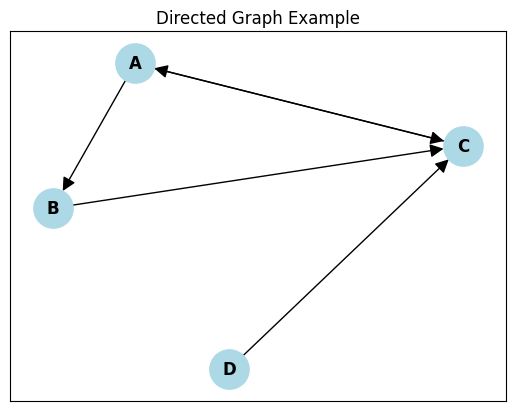

In [2]:
G = nx.DiGraph()

G.add_nodes_from(["A","B", "C", "D"])
G.add_edge("A", "B")
G.add_edge("A", "C")
G.add_edge("B", "C")
G.add_edge("D", "C")
G.add_edge("C","A")

print("Nodes in graph:", G.nodes())
print("Edges in graph:", G.edges())
print("In-degree of D (incoming arrows):", G.in_degree("D"))
print("Out-degree of A (outgoing arrows):", G.out_degree("A"))

pos = nx.spring_layout(G)
nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    node_size=800,
    font_weight="bold",
    arrows=True,
    arrowsize=20,
)

plt.title("Directed Graph Example")
plt.show()


In [3]:

def pagerank(G, d=0.85, max_iter=100, tol=1e-6):
    nodes = list(G.nodes())
    N = len(nodes)
    if N == 0:
        return {}

    rank = {node: 1.0 / N for node in nodes}

    out_degree = {node: G.out_degree(node) for node in nodes}

    for i in range(max_iter):
        new_rank = {}
        dangling_mass = sum(rank[node] for node in nodes if out_degree[node] == 0)

        for node in nodes:
            rank_sum = (1 - d) / N

            rank_sum += d* dangling_mass / N

            for predecessor in G.predecessors(node):
                rank_sum += d * (rank[predecessor] / out_degree[predecessor])

            new_rank[node] = rank_sum

        diff = sum(abs(new_rank[n] - rank[n]) for n in nodes)
        rank = new_rank
        if diff < tol:
            print(f"Converged after {i + 1} iterations")
            break

    return rank

scores = pagerank(G)
for page, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
    print(f"{page}: {score:.6f}")

Converged after 28 iterations
C: 0.394149
A: 0.372527
B: 0.195824
D: 0.037500
